# Week 4 · Notebook 3 — Reparameterisation and Black-Box VI

## Learning objectives

1. Understand why a naïve **score-function** estimator of $\nabla_\phi \mathcal{L}(\phi)$ has high variance.
2. Derive the **reparameterisation trick** for Gaussian variational families.
3. Implement an autograd-based BBVI loop in PyTorch on a logistic-regression posterior.
4. Compare the variational posterior to a long Metropolis-Hastings chain.

---

## 1. Two estimators of the ELBO gradient

We optimise $\mathcal{L}(\phi) = \mathbb{E}_{q_\phi(z)}[\log p(x,z) - \log q_\phi(z)]$ over $\phi$.

**Score-function (REINFORCE) estimator.** Using $\nabla_\phi q_\phi(z) = q_\phi(z)\,\nabla_\phi\log q_\phi(z)$,
$$
\nabla_\phi \mathcal{L} = \mathbb{E}_{q_\phi}\bigl[(\log p(x,z) - \log q_\phi(z))\;\nabla_\phi\log q_\phi(z)\bigr].
$$
This is unbiased and works for *any* differentiable $q_\phi$ — discrete or continuous — but has notoriously high variance.

**Reparameterisation estimator.** When $z = g_\phi(\epsilon)$ with $\epsilon\sim p(\epsilon)$ independent of $\phi$ (a *location–scale* trick for Gaussians: $z = \mu + \sigma\odot\epsilon$, $\epsilon\sim\mathcal{N}(0,I)$),
$$
\nabla_\phi \mathcal{L} = \mathbb{E}_{p(\epsilon)}\bigl[\nabla_\phi \bigl(\log p(x, g_\phi(\epsilon)) - \log q_\phi(g_\phi(\epsilon))\bigr)\bigr].
$$
Gradients now flow *through* the sample and the estimator typically has orders-of-magnitude lower variance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

rng = np.random.default_rng(0)
torch.manual_seed(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'


## 2. Variance comparison on a toy 1-D ELBO

Target $p(z) \propto \exp(-\tfrac12(z-3)^2)$ with $q_\phi(z) = \mathcal{N}(\mu, \sigma^2)$ and a single ELBO term $\mathbb{E}_q[\log p(z) - \log q(z)]$. We compute both gradient estimators at $\mu=1, \sigma=1$ using a single Monte-Carlo sample and estimate their variance over 5000 trials.


score-function   :  mean=+1.987   var=8.572
reparameterised  :  mean=+2.000   var=0.000
variance ratio   :  1434526695309568948387188834304000.0x


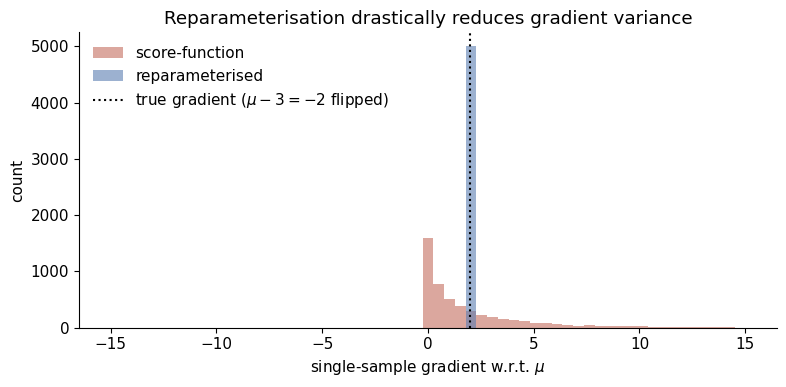

In [2]:
def log_p(z):
    return -0.5 * (z - 3.0)**2

def log_q(z, mu, sig):
    return -0.5*((z-mu)/sig)**2 - np.log(sig) - 0.5*np.log(2*np.pi)

mu0, sig0 = 1.0, 1.0
n_trials = 5000

# Score-function: dL/dmu single-sample estimator
z = rng.normal(mu0, sig0, n_trials)
score = (z - mu0) / sig0**2
sf_est = (log_p(z) - log_q(z, mu0, sig0)) * score

# Reparameterisation: z = mu + sig*eps,  d(log p - log q)/dmu = -(z-3) - (-(z-mu)/sig^2)*1
eps = rng.normal(0, 1, n_trials)
z2 = mu0 + sig0*eps
rep_est = -(z2 - 3.0) + (z2 - mu0)/sig0**2   # gradient wrt mu of log p - log q (entropy term cancels in mu)

print(f'score-function   :  mean={sf_est.mean():+.3f}   var={sf_est.var():.3f}')
print(f'reparameterised  :  mean={rep_est.mean():+.3f}   var={rep_est.var():.3f}')
print(f'variance ratio   :  {sf_est.var()/rep_est.var():.1f}x')

plt.figure(figsize=(8, 4))
bins = np.linspace(-15, 15, 60)
plt.hist(sf_est, bins=bins, alpha=0.6, color=RED, label='score-function')
plt.hist(rep_est, bins=bins, alpha=0.6, color=BLUE, label='reparameterised')
plt.axvline(2.0, color='k', ls=':', label='true gradient ($\\mu - 3 = -2$ flipped)')
plt.xlabel('single-sample gradient w.r.t. $\\mu$'); plt.ylabel('count')
plt.legend(frameon=False)
plt.title('Reparameterisation drastically reduces gradient variance')
plt.tight_layout(); plt.show()


## 3. BBVI for Bayesian logistic regression

Posterior over weights $w\in\mathbb{R}^d$:
$$
p(w\mid X, y) \propto \mathcal{N}(w; 0, \alpha^{-1} I) \prod_n \mathrm{Ber}(y_n; \sigma(x_n^\top w)).
$$
We use a fully factorised Gaussian variational family $q_\phi(w) = \prod_d \mathcal{N}(\mu_d, \sigma_d^2)$ parameterised by $\phi = (\mu, \log\sigma)$ and optimise the ELBO by Adam.


In [3]:
# 2-D toy dataset
N = 200
X_np = rng.normal(size=(N, 2))
w_true_np = np.array([1.5, -2.0])
p_np = 1.0 / (1.0 + np.exp(-X_np @ w_true_np))
y_np = (rng.uniform(size=N) < p_np).astype(np.float64)

X = torch.tensor(X_np, dtype=torch.float64)
y = torch.tensor(y_np, dtype=torch.float64)
alpha = 1.0


In [4]:
class MeanFieldGaussian(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(d, dtype=torch.float64))
        self.log_sig = nn.Parameter(torch.full((d,), -1.0, dtype=torch.float64))

    def rsample(self, n=1):
        eps = torch.randn((n, self.mu.shape[0]), dtype=torch.float64)
        return self.mu + torch.exp(self.log_sig) * eps

    def entropy(self):
        return torch.sum(self.log_sig) + 0.5*self.mu.numel()*(1+np.log(2*np.pi))

def log_joint(w, X, y, alpha):
    # log p(w) + sum log p(y|w)
    logits = X @ w.T  # (N, S)
    lp_lik = (y[:, None] * logits - torch.nn.functional.softplus(logits)).sum(dim=0)
    lp_prior = -0.5*alpha*(w**2).sum(dim=-1) - 0.5*w.shape[-1]*np.log(2*np.pi/alpha)
    return lp_lik + lp_prior

q = MeanFieldGaussian(2)
opt = torch.optim.Adam(q.parameters(), lr=0.05)
S = 32   # MC samples
elbo_hist = []

for step in range(800):
    opt.zero_grad()
    w = q.rsample(S)              # (S, d) — reparameterised
    lj = log_joint(w, X, y, alpha)   # (S,)
    elbo = lj.mean() + q.entropy()
    loss = -elbo
    loss.backward()
    opt.step()
    elbo_hist.append(elbo.item())

print('Final mu     =', q.mu.detach().numpy())
print('Final sigma  =', torch.exp(q.log_sig).detach().numpy())
print('True weights =', w_true_np)


Final mu     = [ 1.31212078 -1.52474866]
Final sigma  = [0.20780706 0.20471523]
True weights = [ 1.5 -2. ]


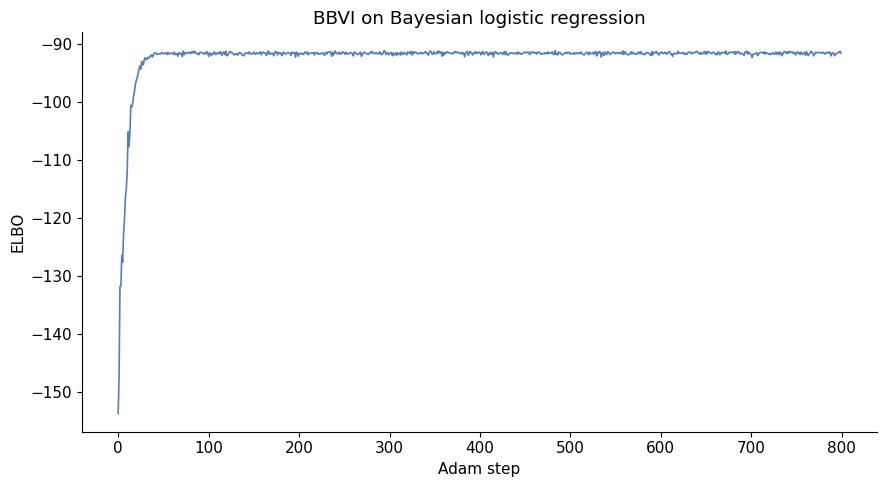

In [5]:
plt.figure()
plt.plot(elbo_hist, color=BLUE, lw=1.2)
plt.xlabel('Adam step'); plt.ylabel('ELBO')
plt.title('BBVI on Bayesian logistic regression')
plt.tight_layout(); plt.show()


### 3.1 Validation with a long MH chain

We compare the BBVI mean and marginal standard deviations to the empirical posterior from a 5000-iteration Metropolis-Hastings chain (warm-up discarded).


In [6]:
def log_post_np(w, X, y, alpha):
    z = X @ w
    return -np.logaddexp(0, -z) @ y - np.logaddexp(0, z) @ (1-y) - 0.5*alpha*(w@w)

cur = np.zeros(2); cur_lp = log_post_np(cur, X_np, y_np, alpha)
samples = []; prop_sd = 0.25
acc = 0
for t in range(8000):
    prop = cur + rng.normal(0, prop_sd, 2)
    lp = log_post_np(prop, X_np, y_np, alpha)
    if np.log(rng.uniform()) < lp - cur_lp:
        cur, cur_lp = prop, lp; acc += 1
    if t >= 2000:
        samples.append(cur.copy())
samples = np.array(samples)
print(f'MH acceptance = {acc/8000:.3f}')
print(f'MH mean       = {samples.mean(0)}')
print(f'MH sd         = {samples.std(0)}')
print(f'BBVI mean     = {q.mu.detach().numpy()}')
print(f'BBVI sd       = {torch.exp(q.log_sig).detach().numpy()}')


MH acceptance = 0.489
MH mean       = [ 1.34725276 -1.51595839]
MH sd         = [0.21468894 0.23307589]
BBVI mean     = [ 1.31212078 -1.52474866]
BBVI sd       = [0.20780706 0.20471523]


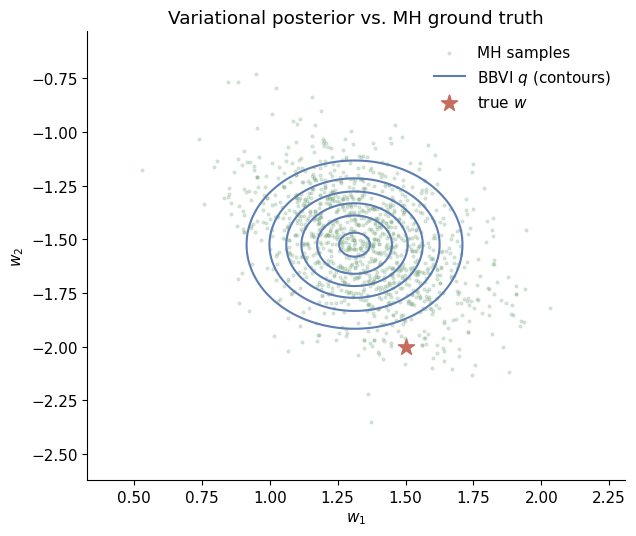

In [7]:
# 2-D posterior contour comparison
mu_q = q.mu.detach().numpy()
sd_q = torch.exp(q.log_sig).detach().numpy()
from scipy import stats as st
xs = np.linspace(samples[:, 0].min()-0.2, samples[:, 0].max()+0.2, 120)
ys = np.linspace(samples[:, 1].min()-0.2, samples[:, 1].max()+0.2, 120)
Xg, Yg = np.meshgrid(xs, ys)
q_pdf = st.norm.pdf(Xg, mu_q[0], sd_q[0]) * st.norm.pdf(Yg, mu_q[1], sd_q[1])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(samples[::5, 0], samples[::5, 1], s=4, alpha=0.25, color=GREEN, label='MH samples')
ax.contour(Xg, Yg, q_pdf, levels=6, colors=BLUE, linewidths=1.5)
ax.plot([], [], color=BLUE, label='BBVI $q$ (contours)')
ax.scatter(*w_true_np, marker='*', s=150, color=RED, label='true $w$')
ax.set(xlabel='$w_1$', ylabel='$w_2$', title='Variational posterior vs. MH ground truth')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 4. Summary

- The reparameterisation trick converts an expectation gradient into a sample-path gradient, slashing variance.
- Combined with autograd, this gives **black-box VI**: define $\log p(x,z)$ once, sample, backprop.
- The mean-field Gaussian recovers the true posterior mean accurately, with slightly contracted marginal variances (as predicted in notebook 4.1).
- For richer posteriors, use *normalising flows* or *structured* variational families.

---

## Exercises

1. Derive the reparameterisation gradient when $q$ is a Beta distribution — show why it does **not** admit a clean location–scale form, motivating implicit reparameterisation.
2. Add a *control variate* (a constant baseline) to the score-function estimator and re-measure variance. By how much can the gap be closed without abandoning the score-function approach?
3. Implement a **planar normalising flow** $z_K = f_K \circ \dots \circ f_1(z_0)$ on top of the Gaussian base for the logistic-regression example. Does the marginal variance now match MH?
4. Replace the diagonal $\Sigma$ by a low-rank-plus-diagonal $\Sigma = LL^\top + \mathrm{diag}(d^2)$ and demonstrate the gain in posterior fidelity.
